# Exploração inicial — dados CONAB

Objetivo: entender o **formato** e a **cobertura** dos dois arquivos da CONAB que sobreviveram ao filtro do período do projeto (2015-01 → 2026-06, chave `sigla_uf` × `ano_mes`).

Relacionado ao ticket [T-016](../tickets/01-coleta/T-016-conab.md).

## Os dois arquivos

| Arquivo | Cobertura | Granularidade nativa |
|---|---|---|
| `SerieHistoricaGraos.txt` | 1976/77 → 2025/26 | UF × safra × produto |
| `OfertaDemanda.txt` | 1999/00 → 2025/26 | **Brasil** × safra × produto |

Baixados de <https://portaldeinformacoes.conab.gov.br/download-arquivos.html>

> **Nota sobre a fonte:** a URL do site antigo que consta no T-016 (`conab.gov.br/info-agro/safras/serie-historica-das-safras`) está fora do ar — redireciona para a home do gov.br. O Portal de Informações é o caminho vivo, e entrega **CSV plano**, não os XLS com cabeçalho mesclado que o ticket previa.

## Os outros 4 arquivos, e por que ficaram de fora

| Arquivo | Início | Motivo da exclusão |
|---|---|---|
| `Estoques.txt` | 2022 | cobre só ~34% do período do projeto |
| `CustoProducao.txt` | 2018 | 1.580 linhas para 9 anos × produtos × UFs — esparso demais |
| `PrecosMensalUF.txt` | 2025 | 2 anos contra 11 |
| `PrecoMinimo.txt` | 2014 | preço administrado por portaria, não é regressor |

In [1]:
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

RAW = "../data/raw/conab/"

---
## 1. Série Histórica de Grãos

Três detalhes de leitura, todos verificados no arquivo bruto:

1. **`encoding="latin1"`** — tem acento em `1ª SAFRA`; ler como UTF-8 quebra.
2. **Separador `;`**, decimal `.` (ponto) — este arquivo usa ponto, mas o `OfertaDemanda` usa **vírgula**. Os dois não podem ser lidos com os mesmos parâmetros.
3. **Colunas de texto vêm com padding à direita** (`"ARROZ                "`). Sem `.str.strip()`, todo filtro por igualdade falha silenciosamente.

In [2]:
graos = pd.read_csv(RAW + "SerieHistoricaGraos.txt", sep=";", encoding="latin1")

# padding à direita em toda coluna de texto
for c in graos.select_dtypes("object"):
    graos[c] = graos[c].str.strip()

print(graos.shape)
graos.head(10)

(28447, 8)


,ano_agricola,dsc_safra_previsao,uf,produto,id_produto,area_plantada_mil_ha,producao_mil_t,produtividade_mil_ha_mil_t
0,1976/77,UNICA,AC,ALGODAO EM CAROCO,4585,0.0,0.0,0.0
1,1976/77,UNICA,AL,ALGODAO EM CAROCO,4585,99.3,20.0,0.2
2,1976/77,UNICA,AM,ALGODAO EM CAROCO,4585,0.0,0.0,0.0
3,1976/77,UNICA,AP,ALGODAO EM CAROCO,4585,0.0,0.0,0.0
4,1976/77,UNICA,BA,ALGODAO EM CAROCO,4585,123.4,23.3,0.2
5,1976/77,UNICA,CE,ALGODAO EM CAROCO,4585,1296.0,233.3,0.2
6,1976/77,UNICA,DF,ALGODAO EM CAROCO,4585,0.0,0.0,0.0
7,1976/77,UNICA,ES,ALGODAO EM CAROCO,4585,0.0,0.0,0.0
8,1976/77,UNICA,GO,ALGODAO EM CAROCO,4585,73.1,80.6,1.1
9,1976/77,UNICA,MA,ALGODAO EM CAROCO,4585,44.4,6.7,0.2


In [3]:
graos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28447 entries, 0 to 28446
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ano_agricola                28447 non-null  object 
 1   dsc_safra_previsao          28447 non-null  object 
 2   uf                          28447 non-null  object 
 3   produto                     28447 non-null  object 
 4   id_produto                  28447 non-null  int64  
 5   area_plantada_mil_ha        28447 non-null  float64
 6   producao_mil_t              28447 non-null  float64
 7   produtividade_mil_ha_mil_t  28447 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 1.7+ MB


### Dicionário das colunas

| Coluna | Significado |
|---|---|
| `ano_agricola` | safra no formato `2024/25` — **não é ano-calendário** |
| `dsc_safra_previsao` | `UNICA`, `1ª SAFRA`, `2ª SAFRA`, `3ª SAFRA` |
| `uf` | sigla da UF (27 unidades, inclui DF) |
| `produto` | 18 produtos |
| `area_plantada_mil_ha` | mil hectares |
| `producao_mil_t` | mil toneladas |
| `produtividade_mil_ha_mil_t` | **kg/ha**, apesar do nome sugerir uma razão de mil/mil |

In [4]:
print("safras: ", graos["ano_agricola"].min(), "->", graos["ano_agricola"].max())
print("UFs:    ", graos["uf"].nunique())
print()
print(graos["dsc_safra_previsao"].value_counts())
print()
print(sorted(graos["produto"].unique()))

safras:  1976 -> 2025/26
UFs:     27

dsc_safra_previsao
UNICA       18803
1ª SAFRA     4053
2ª SAFRA     4052
3ª SAFRA     1539
Name: count, dtype: int64

['ALGODAO EM CAROCO', 'ALGODAO EM PLUMA', 'AMENDOIM', 'ARROZ', 'AVEIA', 'CANOLA', 'CAROCO DE ALGODAO', 'CENTEIO', 'CEVADA', 'FEIJAO', 'GERGELIM', 'GIRASSOL', 'MAMONA EM BAGA', 'MILHO', 'SOJA', 'SORGO GRANIFERO', 'TRIGO', 'TRITICALE']


### ⚠️ Armadilha 1 — a granularidade não é `produto × uf × safra`

Feijão e milho têm **múltiplas safras no mesmo ano agrícola**. A chave real inclui `dsc_safra_previsao`.

Um `merge` por (`uf`, `produto`, `ano_agricola`) **duplica linhas** — 3× para feijão. É o erro que o T-024 chama de "o mais caro desta etapa".

In [5]:
cesta = ["ARROZ", "FEIJAO", "MILHO", "SOJA", "TRIGO"]

# quantas safras cada produto da cesta tem por ano/UF?
(
    graos[graos["produto"].isin(cesta)]
    .groupby("produto")["dsc_safra_previsao"]
    .value_counts()
    .unstack(fill_value=0)
)

dsc_safra_previsao,1ª SAFRA,2ª SAFRA,3ª SAFRA,UNICA
produto,,,,
ARROZ,0,0,0,1350
FEIJAO,1350,1350,1350,0
MILHO,1350,1350,189,0
SOJA,0,0,0,1350
TRIGO,0,0,0,1350


In [6]:
# prova da duplicação: feijão no RS aparece 3x por safra
graos[
    (graos["produto"] == "FEIJAO")
    & (graos["uf"] == "RS")
    & (graos["ano_agricola"] == "2023/24")
]

,ano_agricola,dsc_safra_previsao,uf,produto,id_produto,area_plantada_mil_ha,producao_mil_t,produtividade_mil_ha_mil_t
17063,2023/24,1ª SAFRA,RS,FEIJAO,8380,28.2,53.0,1.9
17064,2023/24,2ª SAFRA,RS,FEIJAO,8380,20.3,18.7,0.9
17065,2023/24,3ª SAFRA,RS,FEIJAO,8380,0.0,0.0,0.0


### ⚠️ Armadilha 2 — 61% das linhas têm produção zero

A CONAB preenche a grade completa UF × produto × safra, inclusive onde a cultura **nunca foi plantada**. A célula abaixo mostra as UFs que nunca produziram soja em 50 anos de série: `ES`, `PB`, `RJ`, `RN`, `SE`.

Esses zeros são *"não se aplica"*, não *"a safra foi perdida"*.

Tratar os dois como o mesmo número contamina qualquer média, desvio ou correlação. **Zeros estruturais devem virar `NaN`** antes de qualquer estatística.

> Nem todo zero é estrutural, porém. Uma UF que produzia e parou, ou que teve perda total num ano, também aparece como zero. O critério da célula abaixo — máximo zero em **toda** a série — isola só o caso estrutural; o recorte mais adiante é mais grosseiro e zera tudo, o que é aceitável para exploração mas não para o dado final.

In [7]:
z = (graos["producao_mil_t"] == 0).mean()
print(f"linhas com producao = 0: {z:.1%}")

# UFs onde soja é sempre zero -> zero estrutural, não quebra de safra
soja = graos[graos["produto"] == "SOJA"].groupby("uf")["producao_mil_t"].max()
print("\nUFs que nunca produziram soja:", sorted(soja[soja == 0].index.tolist()))

linhas com producao = 0: 61.4%

UFs que nunca produziram soja: ['ES', 'PB', 'RJ', 'RN', 'SE']


In [8]:
# recorte do período do projeto (2015+), só produtos da cesta
graos["ano_inicio"] = graos["ano_agricola"].str[:4].astype(int)

recorte = graos[(graos["ano_inicio"] >= 2015) & (graos["produto"].isin(cesta))].copy()
recorte.loc[recorte["producao_mil_t"] == 0, "producao_mil_t"] = pd.NA

print(f"{len(recorte)} linhas | {recorte['ano_inicio'].min()}-{recorte['ano_inicio'].max()}")
recorte.head()

2565 linhas | 2015-2025


,ano_agricola,dsc_safra_previsao,uf,produto,id_produto,area_plantada_mil_ha,producao_mil_t,produtividade_mil_ha_mil_t,ano_inicio
6189,2015/16,UNICA,AC,ARROZ,4684,5.1,6.9,1.4,2015
6190,2015/16,UNICA,AL,ARROZ,4684,3.0,17.2,5.7,2015
6191,2015/16,UNICA,AM,ARROZ,4684,1.9,4.4,2.3,2015
6192,2015/16,UNICA,AP,ARROZ,4684,1.5,1.4,0.9,2015
6193,2015/16,UNICA,BA,ARROZ,4684,7.8,4.0,0.5,2015


<Axes: title={'center': 'Produção nacional por safra (mil t)'}, xlabel='ano_agricola'>

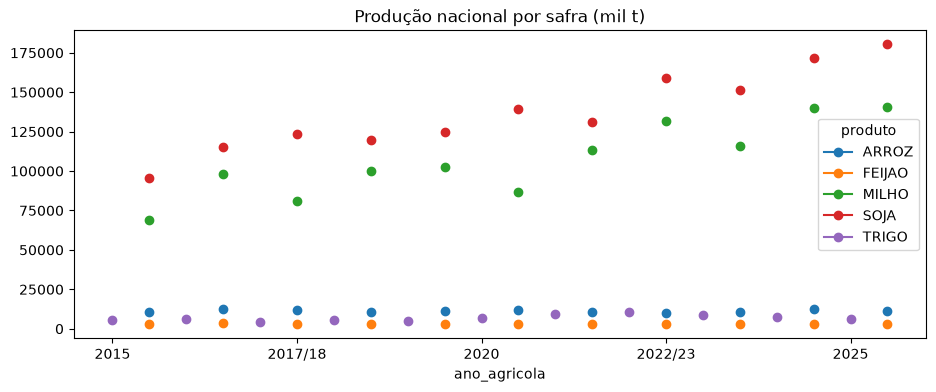

In [9]:
# produção por safra dos produtos da cesta (soma nacional)
(
    recorte.groupby(["ano_agricola", "produto"])["producao_mil_t"]
    .sum()
    .unstack()
    .plot(figsize=(11, 4), marker="o", title="Produção nacional por safra (mil t)")
)

---
## 2. Oferta e Demanda

Arquivo pequeno (119 linhas) e **nacional** — não tem coluna de UF.

Aqui o decimal é **vírgula**, então precisa de `decimal=","`. Sem isso, o pandas lê tudo como texto e as colunas numéricas viram `object` — sem erro nenhum, só resultados errados lá na frente.

In [10]:
oferta = pd.read_csv(
    RAW + "OfertaDemanda.txt", sep=";", encoding="latin1", decimal=","
)

for c in oferta.select_dtypes("object"):
    oferta[c] = oferta[c].str.strip()

print(oferta.shape)
oferta.head(10)

(119, 9)


,produto,id_produto,dsc_safra,estoque_inicial_1000t,producao_1000t,importacao_1000t,consumo_1000t,exportacao_1000t,estoque_final_1000t
0,ALGODAO EM PLUMA,11182,1999/00,380.090,700.3,299.900,885.0,28.500,466.790
1,ALGODAO EM PLUMA,11182,2000/01,466.790,938.8,81.300,865.0,147.300,474.590
2,ALGODAO EM PLUMA,11182,2001/02,474.590,766.2,67.600,815.0,109.600,383.790
3,ALGODAO EM PLUMA,11182,2002/03,383.790,847.5,118.900,830.0,175.400,344.790
4,ALGODAO EM PLUMA,11182,2003/04,344.790,1309.4,105.200,903.4,331.000,524.990
5,ALGODAO EM PLUMA,11182,2004/05,524.990,1298.7,37.621,945.9,390.963,524.448
6,ALGODAO EM PLUMA,11182,2005/06,524.448,1037.8,81.600,983.4,304.500,355.948
7,ALGODAO EM PLUMA,11182,2006/07,355.948,1524.0,96.781,990.0,419.400,567.329
8,ALGODAO EM PLUMA,11182,2007/08,567.329,1602.2,33.710,995.3,532.949,674.990
9,ALGODAO EM PLUMA,11182,2008/09,674.990,1213.7,14.459,1004.1,504.900,394.149


In [11]:
oferta.info()
print()
print("produtos:", oferta["produto"].unique().tolist())
print("safras:  ", oferta["dsc_safra"].min(), "->", oferta["dsc_safra"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   produto                119 non-null    object 
 1   id_produto             119 non-null    int64  
 2   dsc_safra              119 non-null    object 
 3   estoque_inicial_1000t  119 non-null    float64
 4   producao_1000t         119 non-null    float64
 5   importacao_1000t       119 non-null    float64
 6   consumo_1000t          119 non-null    float64
 7   exportacao_1000t       119 non-null    float64
 8   estoque_final_1000t    119 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 8.5+ KB

produtos: ['ALGODAO EM PLUMA', 'ARROZ', 'FEIJAO', 'MILHO', 'SOJA', 'TRIGO']
safras:   1999/00 -> 2025/26


### A variável que justifica este arquivo: **estoque / consumo**

O T-016 diz no Contexto que estoque é *"a variável que explica por que uma quebra de safra às vezes não vira alta de preço — tem amortecedor"*.

A razão `estoque_final ÷ consumo` é a melhor forma dessa ideia:

- é **adimensional** (meses de consumo em estoque), então compara entre produtos;
- **não cresce com o tempo** — ao contrário do estoque absoluto. Isso importa porque a armadilha nº 1 do [T-031](../tickets/03-analise/T-031-correlacao-lag.md) é justamente correlação espúria por tendência comum.

<Axes: title={'center': 'Relação estoque/consumo por safra (quanto menor, mais apertado o mercado)'}, xlabel='dsc_safra'>

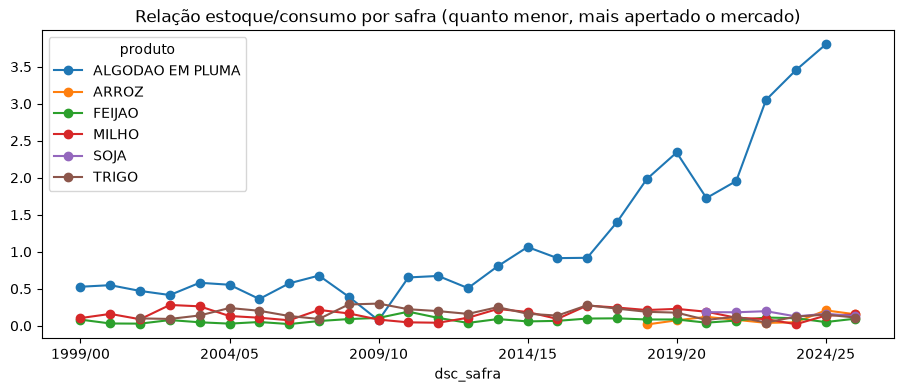

In [12]:
oferta["estoque_consumo"] = oferta["estoque_final_1000t"] / oferta["consumo_1000t"]

(
    oferta.pivot_table(
        index="dsc_safra", columns="produto", values="estoque_consumo"
    ).plot(
        figsize=(11, 4),
        marker="o",
        title="Relação estoque/consumo por safra (quanto menor, mais apertado o mercado)",
    )
)

In [13]:
oferta[oferta["produto"].isin(["ARROZ", "FEIJAO"])].tail(12)

,produto,id_produto,dsc_safra,estoque_inicial_1000t,producao_1000t,importacao_1000t,consumo_1000t,exportacao_1000t,estoque_final_1000t,estoque_consumo
49,FEIJAO,3944,2014/15,303.8,3210.2,156.700,3350.0,122.6,198.100,0.059134
50,FEIJAO,3944,2015/16,198.1,2512.9,325.000,2800.0,50.0,186.000,0.066429
51,FEIJAO,3944,2016/17,208.3,3399.5,137.600,3300.0,122.6,322.800,0.097818
52,FEIJAO,3944,2017/18,322.8,3116.1,81.100,3050.0,162.7,307.300,0.100754
53,FEIJAO,3944,2018/19,307.3,3017.7,150.800,3050.0,166.1,259.700,0.085148
54,FEIJAO,3944,2019/20,259.7,3222.1,113.600,3150.0,176.7,268.700,0.085302
55,FEIJAO,3944,2020/21,268.7,2893.8,83.100,2900.0,223.7,121.900,0.042034
56,FEIJAO,3944,2021/22,121.9,2990.2,76.100,2850.0,136.1,202.100,0.070912
57,FEIJAO,3944,2022/23,202.1,3036.7,69.000,2850.0,139.0,318.800,0.111860
58,FEIJAO,3944,2023/24,318.8,3198.6,22.200,2900.0,343.6,296.000,0.102069


---
## 3. Conclusões para o T-016 / T-031

### Formato
CSV plano, header único, sem célula mesclada. **A previsão de 4h do ticket está superestimada** para estes dois arquivos — o parsing é uma linha de `read_csv` cada. O que dá trabalho não é ler, é reconciliar a granularidade.

### O problema de frequência (o ponto central)

O alvo do projeto é **mensal** (`var_pct_cesta_mm`). Estes dois arquivos são **anuais por safra**.

Ao expandir safra → 12 meses, a série fica **constante o ano inteiro e salta uma vez por ano**. Correlacionar isso contra o alvo mensal não mede o que parece:

- as ~130 linhas mensais **não são independentes** — são ~11 observações repetidas 12×;
- o p-valor calculado sobre n=130 fica otimista por um fator grande;
- isso viola o critério de aceite do T-031: *"toda correlação relatada vem acompanhada de p-valor e tamanho da amostra"*. O n honesto aqui é ~11, não 130.

**Duas saídas honestas** (decidir antes de rodar a CCF):
1. reportar a correlação safra × preço em **base anual**, com n real declarado;
2. usar produção como **variável de nível/contexto** (patamar de oferta da UF), não como série temporal.

A opção 2 casa melhor com o T-041, que consome `lags_otimos.csv` para seleção de features.

### Sobre o `OfertaDemanda`
Sendo nacional, ele é **idêntico para todas as UFs no mesmo mês**. Numa matriz UF × mês, vira quase uma proxy de tempo. Entra como *broadcast nacional* (igual `macro_br_mes` no T-024), nunca como variável que varia por UF.

### Recomendação
O T-016 é **P2** e diz *"se o tempo apertar, corte este ticket"*. Nada aqui contradiz isso: a CONAB não traz nenhuma variável **mensal por UF** que o LSPA (T-012) não cubra melhor.

O que ela traz de único é **estoque** — e a versão com histórico suficiente é nacional. Se for aproveitar uma coisa só deste ticket, que seja a série `estoque_consumo` como feature nacional defasada.